# Generate Embeddings for Euclid-DESI Cross-Modal Dataset

This notebook generates embeddings for individual modalities and combined modalities:
- **Euclid image** embedding (using HSCImage codec)
- **DESI spectrum** embedding  
- **Combined Euclid+DESI+Z** embedding

Test on 10 samples from the local cache.

## Imports and Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from aion import AION
from aion.codecs import CodecManager
from aion.datasets import EuclidDESIDataset, collate_modalities
from aion.modalities import HSCImage

CACHE_DIR = "../data/"
MAX_ENTRIES = 10
BATCH_SIZE = 5
device = 'cpu'

print(f"Using device: {device}")
print(f"Max entries to process: {MAX_ENTRIES}")

Using device: cpu
Max entries to process: 10


## Load AION Model and Codec Manager

In [2]:
print("Loading AION model...")
model = AION.from_pretrained('polymathic-ai/aion-base').to(device).eval()

print("Loading Codec Manager...")
codec_manager = CodecManager(device=device)

print("Model and codec manager loaded successfully")

Loading AION model...
Loading Codec Manager...
Model and codec manager loaded successfully


## Load Euclid-DESI Dataset

In [ ]:
print(f"Loading dataset from {CACHE_DIR}...")
dataset = EuclidDESIDataset(
    cache_dir=CACHE_DIR,
    mode="streaming",
    device=device,
    max_entries=MAX_ENTRIES,
    split='train'
)

total_samples = len(dataset)
limit = min(total_samples, MAX_ENTRIES)

print(f"Dataset has {total_samples} samples")
print(f"Processing {limit} samples")

subset_indices = list(range(limit))
subset = torch.utils.data.Subset(dataset, subset_indices)

loader = DataLoader(
    subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_modalities
)

print(f"DataLoader created with batch_size={BATCH_SIZE}")

Loading dataset from ../data/...
No cache found. Streaming samples from msiudek/astroPT_euclid_Q1_desi_dr1_dataset...


Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Streaming samples:   0%|          | 0/10 [00:00<?, ?it/s]

## Generate Embeddings

For each batch:
1. Encode **Euclid image** only (converted to HSCImage)
2. Encode **DESI spectrum** only
3. Encode **combined** Euclid+DESI+Z
4. Extract embeddings by passing tokens to model and averaging

In [ ]:
from tqdm.auto import tqdm

results = []
processed = 0

with torch.inference_mode():
    for batch_idx, (rgb_image, euclid_image, desi_spectrum, z_redshift) in tqdm(enumerate(loader)):
        print(f"\nBatch {batch_idx + 1}/{len(loader)}")
        batch_len = euclid_image.flux.shape[0]

        rgb_image = rgb_image.to(device)
        euclid_image.flux = euclid_image.flux.to(device)
        desi_spectrum.flux = desi_spectrum.flux.to(device)
        desi_spectrum.ivar = desi_spectrum.ivar.to(device)
        desi_spectrum.wavelength = desi_spectrum.wavelength.to(device)
        desi_spectrum.mask = desi_spectrum.mask.to(device)
        z_redshift.value = z_redshift.value.to(device)
        
        euclid_as_hsc = HSCImage(flux=euclid_image.flux, bands=euclid_image.bands)
        
        tokens_euclid = codec_manager.encode(euclid_as_hsc)
        tokens_desi = codec_manager.encode(desi_spectrum)
        tokens_z = codec_manager.encode(z_redshift)
        tokens_combined = codec_manager.encode(euclid_as_hsc, desi_spectrum, z_redshift)
        
        embedding_euclid = model.encode(tokens_euclid).mean(dim=1)
        embedding_desi = model.encode(tokens_desi).mean(dim=1)
        embedding_combined = model.encode(tokens_combined).mean(dim=1)

        for i in range(batch_len):
            record = {
                "index": processed + i,
                "redshift": z_redshift.value[i].item(),
                "embedding_euclid": embedding_euclid[i].cpu(),
                "embedding_desi": embedding_desi[i].cpu(),
                "embedding_euclid_desi_z": embedding_combined[i].cpu(),
            }
            results.append(record)
        
        processed += batch_len

print(f"\n{'='*60}")
print(f"Generated {len(results)} embeddings")
print(f"{'='*60}")


Batch 1/20
  RGB shape: torch.Size([5, 224, 224, 3])
  Euclid flux shape: torch.Size([5, 4, 160, 160])
  DESI flux shape: torch.Size([5, 7781])
  Redshift shape: torch.Size([5, 1])


/home/wassim/Projects/NBody/AION/aion/datasets.py:295: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask=torch.tensor(mask, dtype=torch.bool),


  Euclid tokens: torch.Size([5, 576])
  DESI tokens: torch.Size([5, 273])
  Z tokens: torch.Size([5, 1])
  EUCLID Embedding shapes: torch.Size([5, 768])
  DESI Embedding shapes: torch.Size([5, 768])
  Z Embedding shapes: torch.Size([5, 768])
  Combined Embedding shapes: torch.Size([5, 768])

Batch 2/20
  RGB shape: torch.Size([5, 224, 224, 3])
  Euclid flux shape: torch.Size([5, 4, 160, 160])
  DESI flux shape: torch.Size([5, 7781])
  Redshift shape: torch.Size([5, 1])
  Euclid tokens: torch.Size([5, 576])
  DESI tokens: torch.Size([5, 273])
  Z tokens: torch.Size([5, 1])
  EUCLID Embedding shapes: torch.Size([5, 768])
  DESI Embedding shapes: torch.Size([5, 768])
  Z Embedding shapes: torch.Size([5, 768])
  Combined Embedding shapes: torch.Size([5, 768])

Batch 3/20
  RGB shape: torch.Size([5, 224, 224, 3])
  Euclid flux shape: torch.Size([5, 4, 160, 160])
  DESI flux shape: torch.Size([5, 7781])
  Redshift shape: torch.Size([5, 1])
  Euclid tokens: torch.Size([5, 576])
  DESI tokens:

## Display Results

In [ ]:
print(f"Total embeddings: {len(results)}")
print(f"\nFirst embedding:")
print(f"  Index: {results[0]['index']}")
print(f"  Redshift: {results[0]['redshift']:.6f}")
print(f"  Embedding shapes:")
print(f"    Euclid: {results[0]['embedding_euclid'].shape}")
print(f"    DESI: {results[0]['embedding_desi'].shape}")
print(f"    Combined: {results[0]['embedding_euclid_desi_z'].shape}")

## Embedding Analysis

In [ ]:
from embeddings_analyzer import (
    stack_embeddings,
    compute_umap,
    plot_umap_grid,
    compute_pairwise_cosine_similarities,
    plot_cosine_matrix,
    plot_cosine_distributions,
    plot_cosine_vs_redshift,
    compute_nearest_neighbor_agreement,
    plot_nn_agreement
)

redshifts = np.array([r['redshift'] for r in results])

### UMAP Visualization

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


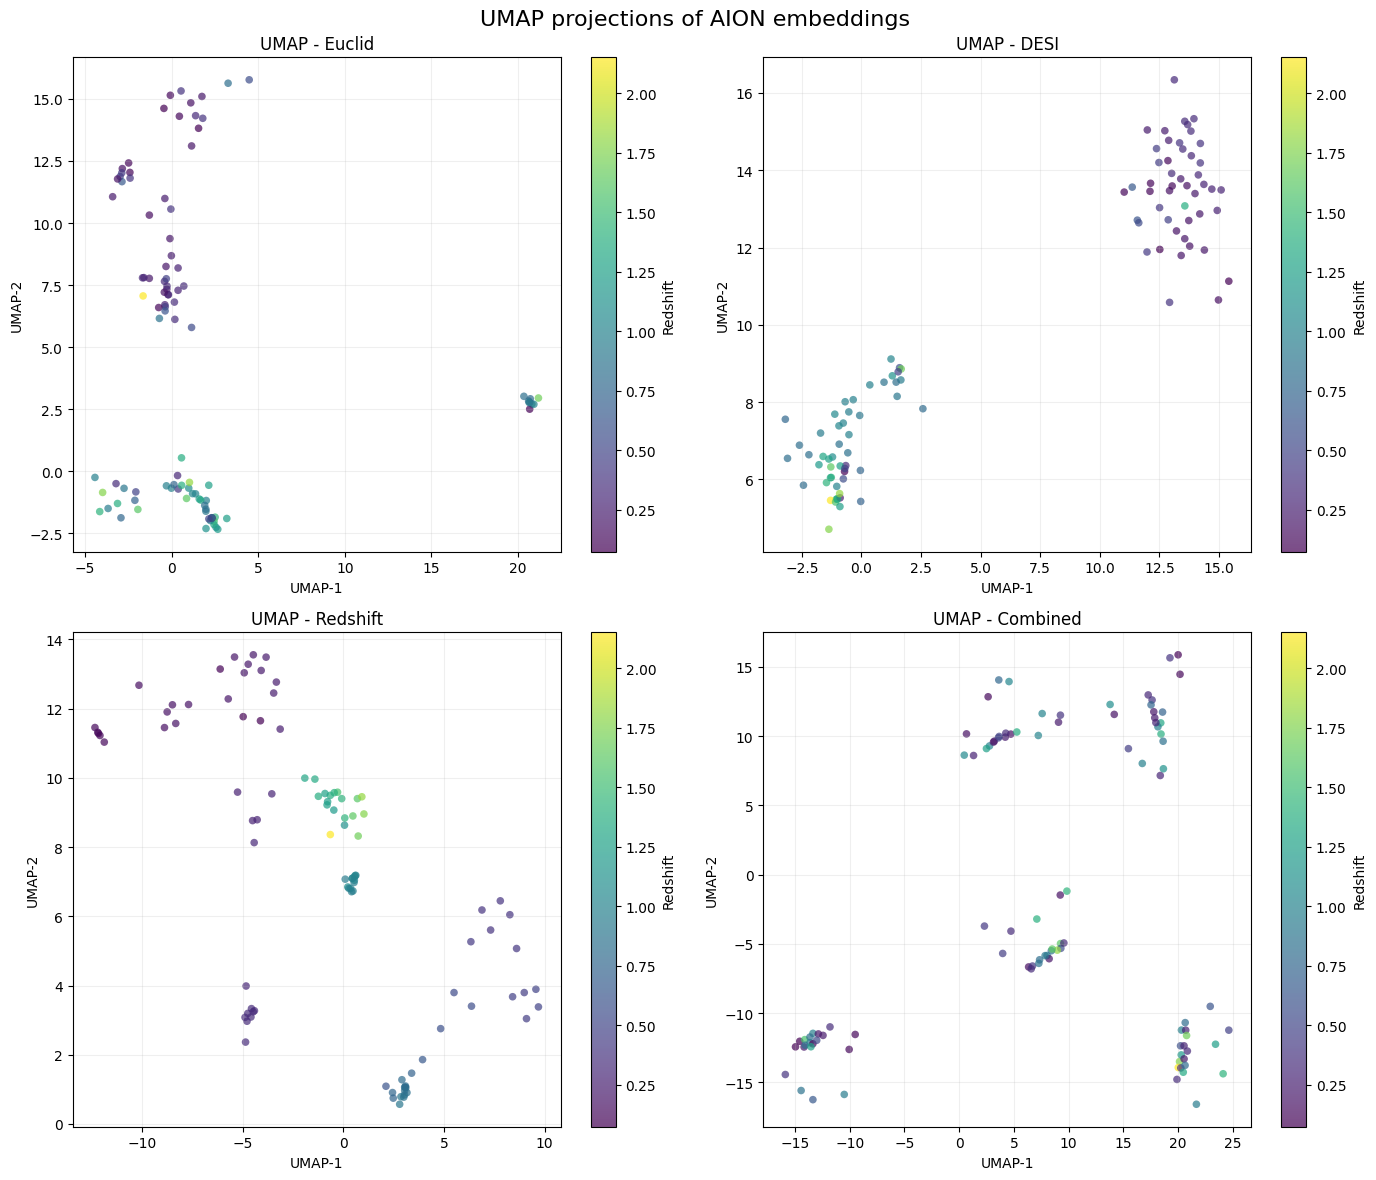

In [ ]:
emb_euclid = stack_embeddings(results, 'embedding_euclid')
emb_desi = stack_embeddings(results, 'embedding_desi')
emb_combined = stack_embeddings(results, 'embedding_euclid_desi_z')

umap_euclid = compute_umap(emb_euclid, n_neighbors=min(5, len(results)-1))
umap_desi = compute_umap(emb_desi, n_neighbors=min(5, len(results)-1))
umap_combined = compute_umap(emb_combined, n_neighbors=min(5, len(results)-1))

coords_dict = {
    'Euclid': umap_euclid,
    'DESI': umap_desi,
    'Combined': umap_combined
}

fig_umap = plot_umap_grid(coords_dict, redshifts)
plt.show()

### Cosine Similarity Analysis

In [ ]:
keys = ['embedding_euclid', 'embedding_desi', 'embedding_euclid_desi_z']
cosine_dict = compute_pairwise_cosine_similarities(results, keys)

fig_matrix = plot_cosine_matrix(cosine_dict, keys)
plt.show()

fig_dist = plot_cosine_distributions(cosine_dict)
plt.show()

### Cosine Similarity vs Redshift

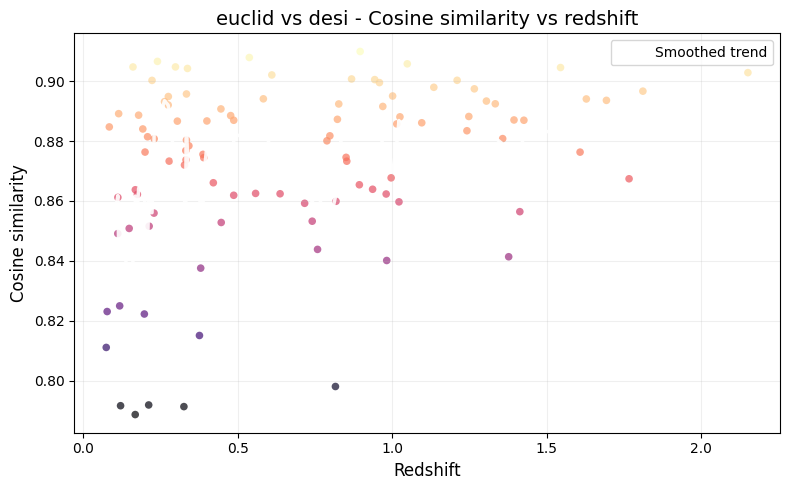

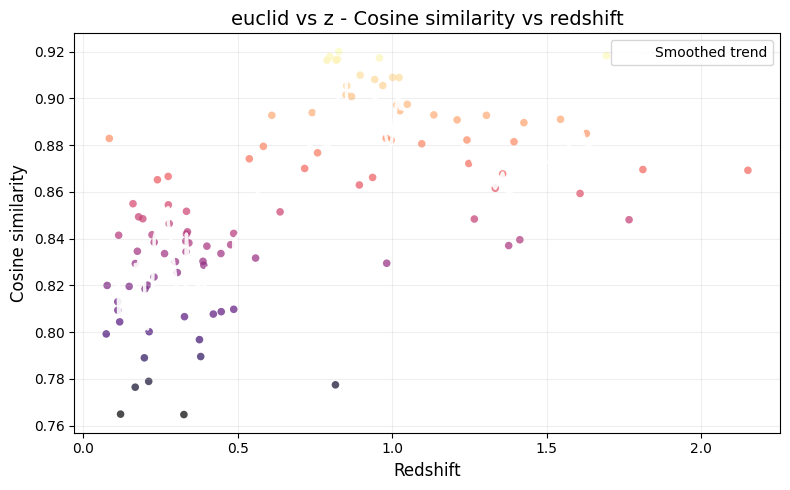

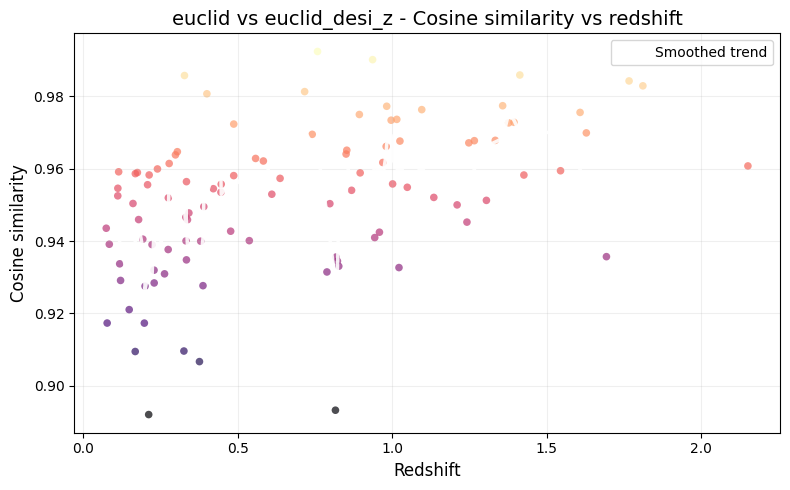

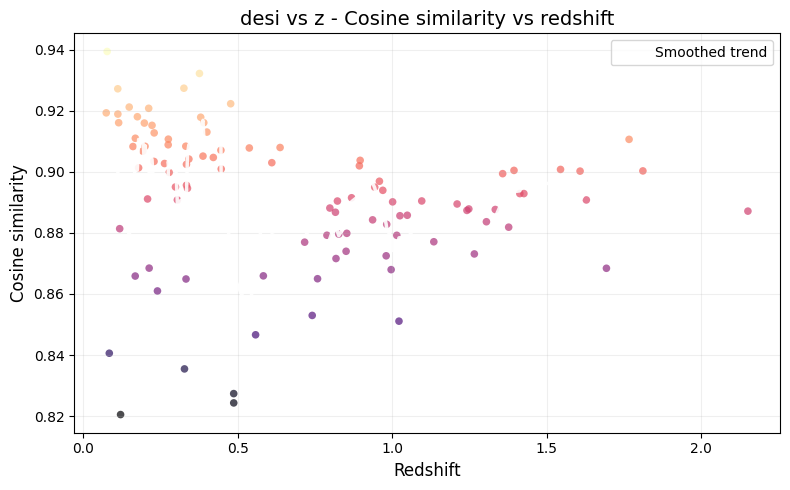

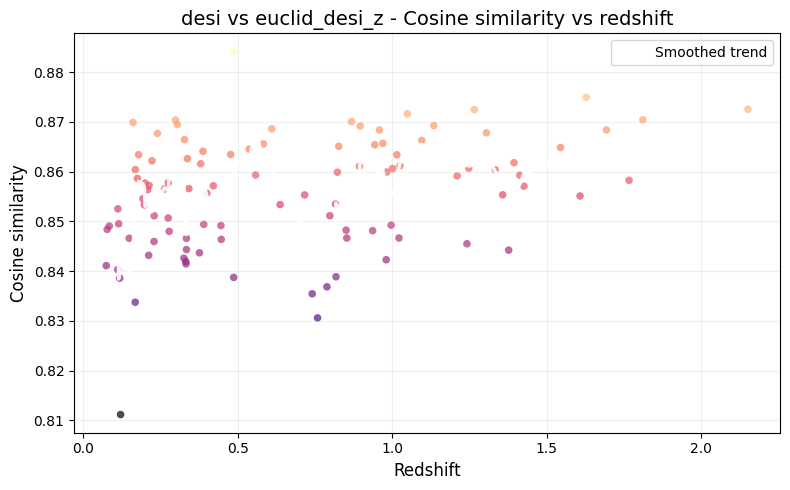

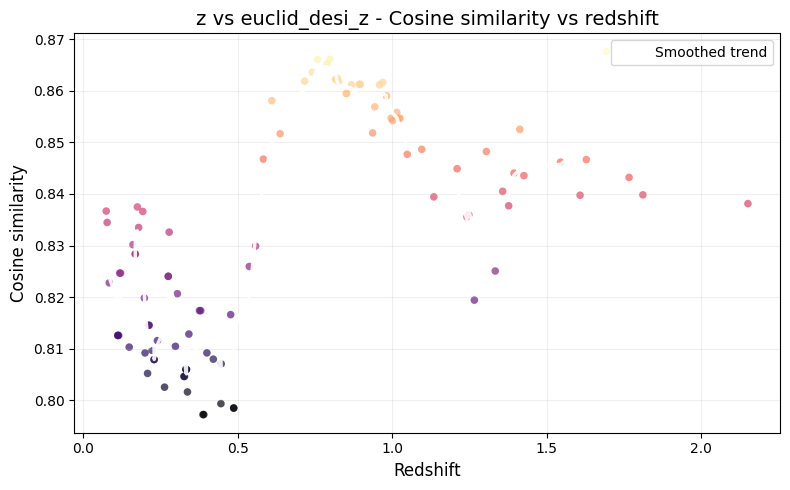

In [ ]:
for (key1, key2), cosine_values in cosine_dict.items():
    label1 = key1.replace('embedding_', '')
    label2 = key2.replace('embedding_', '')
    title = f'{label1} vs {label2} - Cosine similarity vs redshift'
    fig_cos_z = plot_cosine_vs_redshift(cosine_values, redshifts, title)
    if fig_cos_z is not None:
        plt.show()

## Save Embeddings

In [ ]:
output_path = "embeddings_notebook_test.pt"
torch.save(results, output_path)
print(f"Saved {len(results)} embeddings to {output_path}")

Saved 100 embeddings to embeddings_notebook_test.pt
